# DBSCAN Clustering: Discovering Non-Linear Structures in Spatial Data  

**Student Name:**   Keerthi

---

This tutorial demonstrates how DBSCAN identifies clusters of arbitrary shape and detects noise in spatial datasets.  
We compare DBSCAN with K-Means and explore parameter selection using the k-distance graph.

### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors

### Generate Dataset

In [2]:
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

### Visualisation 1: Raw Data

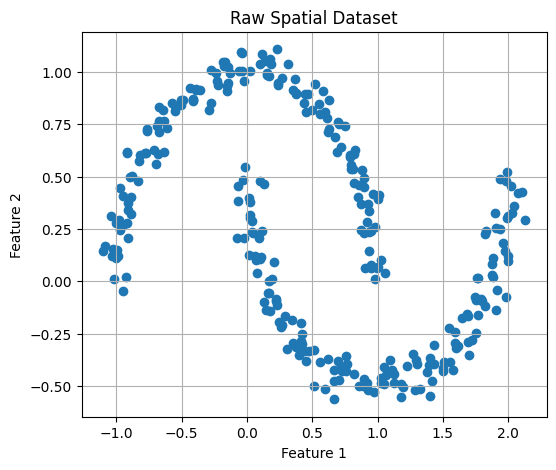

In [14]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1])

plt.title("Raw Spatial Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("moons.png")
plt.grid(True)
plt.show()

## k-Distance Graph for eps Selection

The k-distance graph helps determine an appropriate value for eps by identifying a sharp change in distance values.

### Compute k-distance

In [4]:
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, k-1])

### Visualisation 2: k-distance Graph

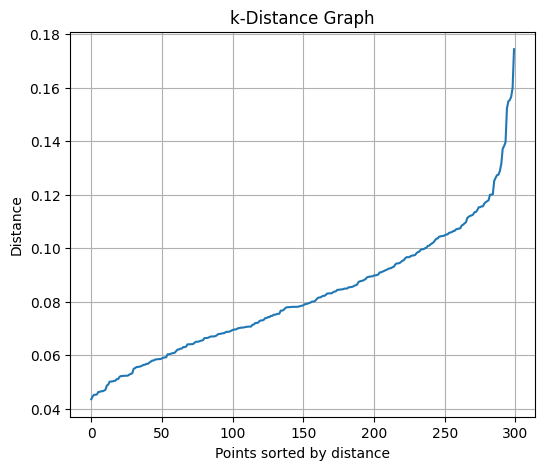

In [15]:
plt.figure(figsize=(6,5))

plt.plot(distances)

plt.title("k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.savefig("k_distance.png")
plt.grid(True)
plt.show()

### Apply DBSCAN

In [6]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

### Visualisation 3: DBSCAN Clusters

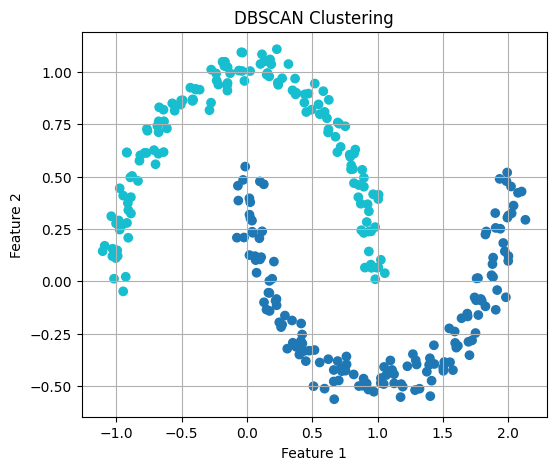

In [16]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10')

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("dbscan.png")
plt.grid(True)
plt.show()

### Visualisation 4: Noise Detection

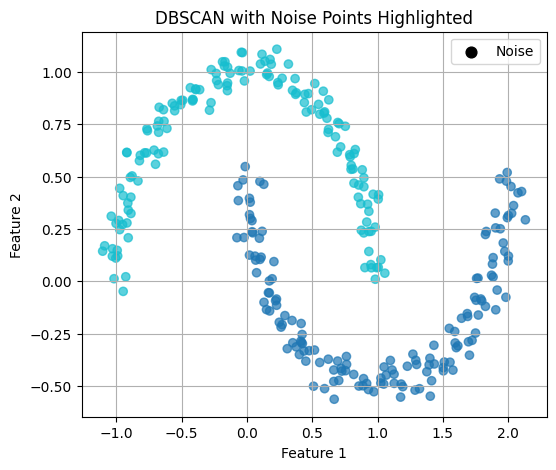

In [22]:
noise = labels == -1

plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', alpha=0.7)

plt.scatter(X[noise,0], X[noise,1],
            c='black', s=60, label='Noise')

plt.title("DBSCAN with Noise Points Highlighted")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.grid(True)

plt.savefig("dbscan_noise.png", dpi=300, bbox_inches='tight')
plt.show()

### K - Means Model

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)

### Visualisation 5: Comparison

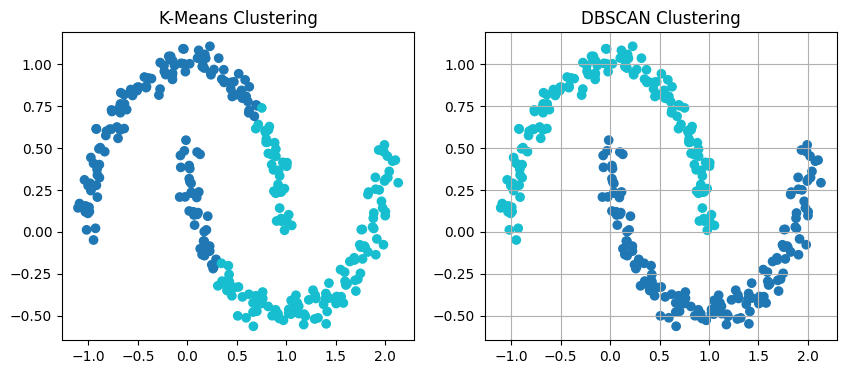

In [18]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].scatter(X[:,0], X[:,1], c=k_labels, cmap='tab10')
ax[0].set_title("K-Means Clustering")

ax[1].scatter(X[:,0], X[:,1], c=labels, cmap='tab10')
ax[1].set_title("DBSCAN Clustering")
plt.savefig("kmeans_dbscan.png")
plt.grid(True)
plt.show()

### Visualisation 6: eps Variation

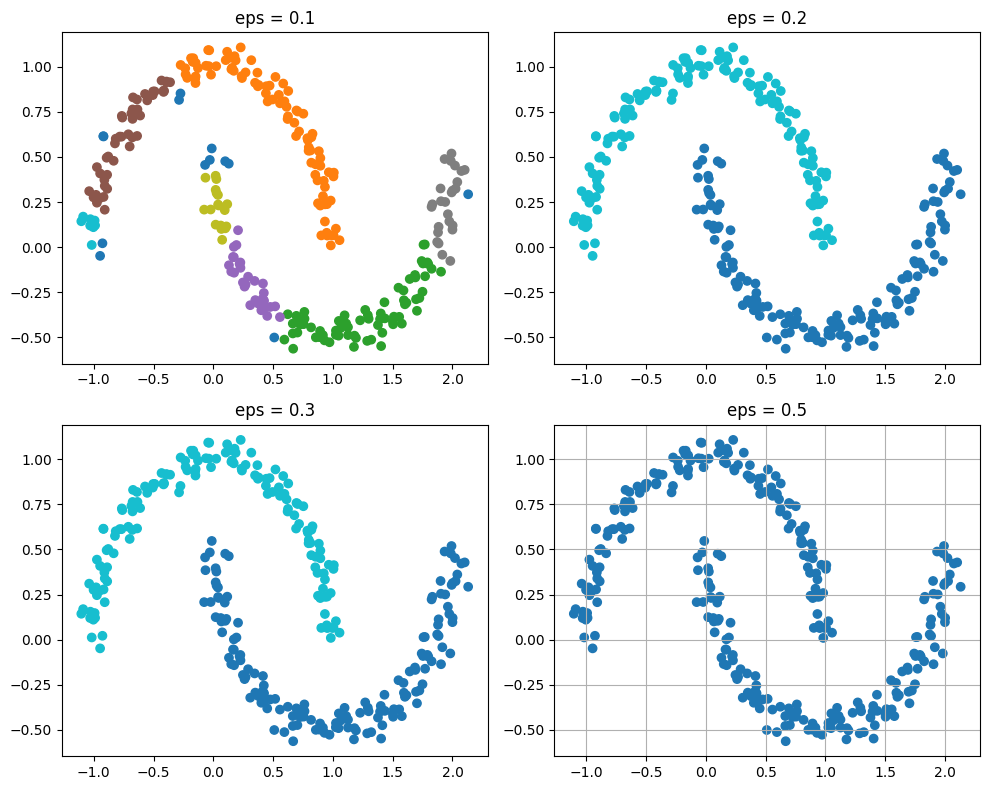

In [19]:
eps_values = [0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(10,8))

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels_temp = db.fit_predict(X)

    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=labels_temp, cmap='tab10')
    plt.title(f"eps = {eps}")

plt.tight_layout()
plt.savefig("dbscan_eps.png")
plt.grid(True)
plt.show()

### Number of Clusters + Noise

In [12]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated clusters:", n_clusters)
print("Noise points:", n_noise)

Estimated clusters: 2
Noise points: 0


### Cluster Distribution

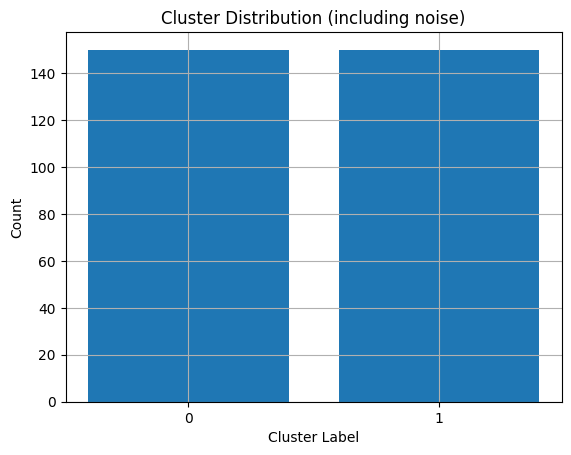

In [20]:
unique, counts = np.unique(labels, return_counts=True)

plt.bar(unique.astype(str), counts)

plt.title("Cluster Distribution (including noise)")
plt.xlabel("Cluster Label")
plt.ylabel("Count")
plt.savefig("cluster_distribution.png")
plt.grid(True)
plt.show()